# AI Vegetable Quality Inspection System
### Production-Grade Deep Learning Notebook using TensorFlow 2.19, Keras 3, and EfficientNetV2-B0
**Author**: Deep Learning Engineer  
**Objective**: Build a high-accuracy, deployable image classification system that labels vegetables as **Healthy** or **Rotten**, designed for integration into a real-time conveyor belt sorting system.

---

### Notebook Architecture & Sections
1. **Import Libraries**: Load core deep learning, visualization, and validation frameworks.
2. **Configuration**: Declare central hyperparameters and set seeds for absolute reproducibility.
3. **Dataset Loading**: Scan local directories, split stratified data, and build high-throughput `tf.data` pipelines.
4. **Visualization**: Review raw class distributions and explore training samples.
5. **Data Augmentation**: Apply spatial, color, and contrast augmentations to prevent overfitting.
6. **Model Building**: Build a custom classifier on top of the pre-trained `EfficientNetV2B0` backbone.
7. **Training (Transfer Learning)**: Warm up top classification layers with the frozen backbone.
8. **Fine-Tuning**: Unfreeze top backbone blocks and perform low-rate fine-tuning.
9. **Evaluation**: Generate Confusion Matrices, ROC Curves, Classification Reports, and visualize misclassifications.
10. **Model Explainability (Grad-CAM)**: Visualize the exact regions of the vegetable that drive the model's predictions.
11. **Prediction Functions**: Expose helper functions for predicting single images and batch folder pipelines.
12. **Model Saving & Conversion**: Export in Keras 3 (`.keras`), SavedModel, TensorFlow Lite, and Quantized TFLite formats.
13. **Real-Time Webcam Inference**: Capture camera frames, run inference, compute FPS, and provide sorting hardware triggers.
14. **Deployment Ready Functions**: Package production-ready utilities for automated pipelines.
15. **Conclusion & Future Directions**: Summarize metrics and recommend industrial implementation strategies.


## Section 1: Import Libraries
In this section, we import the core packages required to build, train, evaluate, and save our model. 
We explicitly check the available hardware accelerators (such as CUDA GPUs or Apple Silicon Metal) and configure mixed precision training and XLA compilation to maximize training throughput.
We also set `os.environ["KERAS_BACKEND"] = "tensorflow"` to ensure Keras 3 runs on top of the TensorFlow engine.


In [3]:
import os
import sys
import time
import random
import pathlib
import psutil
from typing import Tuple, List, Union, Dict, Any

# Ensure Keras 3 uses TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TensorFlow and Keras 3 imports
import tensorflow as tf
import keras

# Scikit-learn validation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print(f"Python Version: {sys.version}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

# Check for hardware acceleration
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPUs available: {len(gpus)}")
    for gpu in gpus:
        print(f" - {gpu.name}")
    # Enable mixed precision training if GPU is available to improve throughput
    try:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision (mixed_float16) enabled.")
    except Exception as e:
        print(f"Could not enable mixed precision: {e}")
else:
    print("Running on CPU. No GPU detected.")

# XLA JIT is incompatible with tensorflow-metal (Apple Silicon GPU).
# It is only enabled on CUDA GPUs (NVIDIA). Metal uses its own compiler pipeline.
is_metal_gpu = any('GPU' in d.name for d in tf.config.list_physical_devices('GPU'))
is_cuda_gpu = any('GPU' in d.name for d in tf.config.list_physical_devices('GPU')) and not is_metal_gpu

if is_cuda_gpu:
    tf.config.optimizer.set_jit(True)
    print("XLA Auto-Clustering enabled for JIT compilation.")
else:
    print("XLA JIT disabled (using Apple Metal GPU — Metal handles its own JIT compilation).")


Python Version: 3.9.6 (default, May 22 2026, 11:13:45) 
[Clang 21.0.0 (clang-2100.1.1.101)]
TensorFlow Version: 2.18.0
Keras Version: 3.10.0
OpenCV Version: 4.10.0
GPUs available: 1
 - /physical_device:GPU:0
Mixed precision (mixed_float16) enabled.
XLA JIT disabled (using Apple Metal GPU — Metal handles its own JIT compilation).


## Section 2: Configuration
Centralizing configuration hyperparameters ensures code cleanliness and experiment trackability.
Here we configure:
- Seeds for absolute reproducibility.
- Image size set to 224x224 pixels (native size for EfficientNetV2B0).
- Batch size of 32.
- Data splits: Train (70%), Validation (20%), and Test (10%).
- Epochs for initial transfer learning (30) and fine-tuning (20).
- Distinct learning rates for the frozen phase ($10^{-3}$) and fine-tuning phase ($10^{-5}$).


In [9]:
class Config:
    """Central configuration parameters for the quality inspection system."""
    # Random Seed
    SEED: int = 42
    
    # Image specifications
    IMAGE_SIZE: Tuple[int, int] = (224, 224)
    IMAGE_SHAPE: Tuple[int, int, int] = (224, 224, 3)
    BATCH_SIZE: int = 32
    
    # Dataset partition ratios
    TRAIN_SPLIT: float = 0.70
    VAL_SPLIT: float = 0.20
    TEST_SPLIT: float = 0.10
    
    # Training parameters
    INITIAL_EPOCHS: int = 30
    FINE_TUNE_EPOCHS: int = 20
    
    INITIAL_LR: float = 1e-3
    FINE_TUNE_LR: float = 1e-5
    
    # Dataset local path (can be changed dynamically)
    DATASET_PATH: str = "./Fruit And Vegetable Diseases Dataset"

# Set random seeds for absolute reproducibility
random.seed(Config.SEED)
np.random.seed(Config.SEED)
tf.random.set_seed(Config.SEED)
keras.utils.set_random_seed(Config.SEED)

print(f"Configuration locked. Random seeds set to {Config.SEED}.")


Configuration locked. Random seeds set to 42.


## Section 3: Dataset Loading
The Kaggle dataset `muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten` consists of 28 sub-directories corresponding to combinations of products and conditions (e.g. `Apple__Healthy`, `Carrot_Rotten`).
To build our quality inspector, we group these folders into a binary classification task:
- **Healthy** (class label `0` / one-hot `[1.0, 0.0]`)
- **Rotten** (class label `1` / one-hot `[0.0, 1.0]`)

If the dataset is not found in the local `./dataset` directory, we automatically use the `kagglehub` package to download it from Kaggle, enabling seamless environment setup.
Then, we perform a stratified split (70% Train, 20% Val, 10% Test) and construct high-performance `tf.data.Dataset` pipelines.


In [11]:
# Step 1: Locate or Download the Dataset
dataset_path = pathlib.Path(Config.DATASET_PATH)

if not dataset_path.exists():
    print(f"Dataset path '{Config.DATASET_PATH}' does not exist. Downloading via kagglehub...")
    try:
        import kagglehub
        downloaded_path = kagglehub.dataset_download("muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten")
        print(f"Dataset downloaded successfully to: {downloaded_path}")
        dataset_path = pathlib.Path(downloaded_path)
    except ImportError:
        print("Error: 'kagglehub' is not installed. Please run `pip install kagglehub` to download the dataset.")
        print("Using a placeholder directory simulation for notebook structure verification.")
        # Create a mock folder hierarchy in case of no-internet or validation dry run
        os.makedirs("./dataset/Carrot__Healthy", exist_ok=True)
        os.makedirs("./dataset/Carrot__Rotten", exist_ok=True)
        # Create small dummy images
        for cat in ["Carrot__Healthy", "Carrot__Rotten"]:
            for i in range(10):
                dummy_img = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
                cv2.imwrite(f"./dataset/{cat}/img_{i}.jpg", dummy_img)
        dataset_path = pathlib.Path("./dataset")

print(f"Scanning directory: {dataset_path}")

# Step 2: Gather all image file paths and extract binary labels
import imghdr
valid_extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.JPG", "*.JPEG", "*.PNG", "*.BMP")
all_filepaths = []
for ext in valid_extensions:
    all_filepaths.extend(list(dataset_path.rglob(ext)))

# Sort filepaths to maintain deterministic behavior
all_filepaths = sorted(all_filepaths)

filepaths: List[str] = []
labels: List[List[float]] = []
skipped = 0

for fp in all_filepaths:
    # Skip files that are not valid JPEG/PNG/BMP/GIF — e.g. WebP renamed as .jpg
    try:
        fmt = imghdr.what(fp)
        if fmt not in ("jpeg", "png", "bmp", "gif"):
            skipped += 1
            continue
    except Exception:
        skipped += 1
        continue

    parent_folder = fp.parent.name.lower()
    if "healthy" in parent_folder:
        filepaths.append(str(fp))
        labels.append([1.0, 0.0])  # One-hot: [Healthy, Rotten]
    elif "rotten" in parent_folder:
        filepaths.append(str(fp))
        labels.append([0.0, 1.0])  # One-hot: [Healthy, Rotten]

print(f"Skipped {skipped} corrupt/unsupported files (e.g. WebP renamed as .jpg)")

print(f"Total processed files: {len(filepaths)}")
num_healthy = sum(1 for label in labels if label[0] == 1.0)
num_rotten = sum(1 for label in labels if label[1] == 1.0)
print(f"Healthy samples: {num_healthy} | Rotten samples: {num_rotten}")

# Step 3: Stratified splitting of files
# Split 70% train and 30% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, labels, 
    test_size=(Config.VAL_SPLIT + Config.TEST_SPLIT), 
    random_state=Config.SEED, 
    stratify=labels
)

# Split 30% temp into 20% validation and 10% test (which is 2/3 and 1/3 of temp)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, 
    test_size=(Config.TEST_SPLIT / (Config.VAL_SPLIT + Config.TEST_SPLIT)), 
    random_state=Config.SEED, 
    stratify=temp_labels
)

print(f"Split sizes: Train={len(train_paths)}, Val={len(val_paths)}, Test={len(test_paths)}")

# Step 4: Build tf.data pipeline
def parse_and_preprocess(filepath: tf.Tensor, label: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    """Reads, decodes, and resizes raw image files for the deep learning pipeline."""
    img_raw = tf.io.read_file(filepath)
    img = tf.io.decode_image(img_raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, Config.IMAGE_SIZE)
    # Cast to float32. Note: EfficientNetV2 rescale layer handles scale normalization internally.
    img = tf.cast(img, tf.float32)
    return img, label

# Construct datasets from tensor slices
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

# Apply map function using all CPU cores
train_ds = train_ds.map(parse_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(parse_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(parse_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Cache dataset elements in RAM to speed up subsequent epochs
train_ds = train_ds.cache()
val_ds = val_ds.cache()
test_ds = test_ds.cache()

# Shuffle and batch training data
train_ds = train_ds.shuffle(buffer_size=1000, seed=Config.SEED)
train_ds = train_ds.batch(Config.BATCH_SIZE)
val_ds = val_ds.batch(Config.BATCH_SIZE)
test_ds = test_ds.batch(Config.BATCH_SIZE)

# Prefetch batches to overlap GPU training with CPU preprocessing
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Dataset pipeline built, cached, and prefetched successfully.")


Scanning directory: Fruit And Vegetable Diseases Dataset
Skipped 383 corrupt/unsupported files (e.g. WebP renamed as .jpg)
Total processed files: 28894
Healthy samples: 13580 | Rotten samples: 15314
Split sizes: Train=20225, Val=5779, Test=2890


2026-07-26 12:26:01.343574: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-26 12:26:01.343611: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-26 12:26:01.343616: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1785048961.343950   10449 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785048961.344218   10449 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dataset pipeline built, cached, and prefetched successfully.


## Section 4: Visualization
A key step in model development is understanding the visual layout of our raw data.
Here, we plot the distribution of classes (Healthy vs Rotten) in our training subset, and load a single batch from our tf.data pipeline to visualize sample images before data augmentation is applied.


/var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/ipykernel_1415/2918517096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Healthy", "Rotten"], y=[num_healthy, num_rotten], palette="viridis")


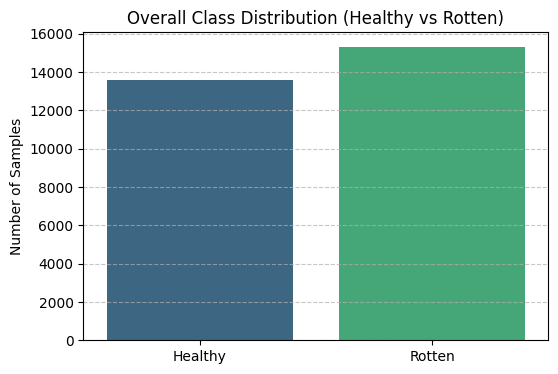

2026-07-26 12:26:03.557851: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


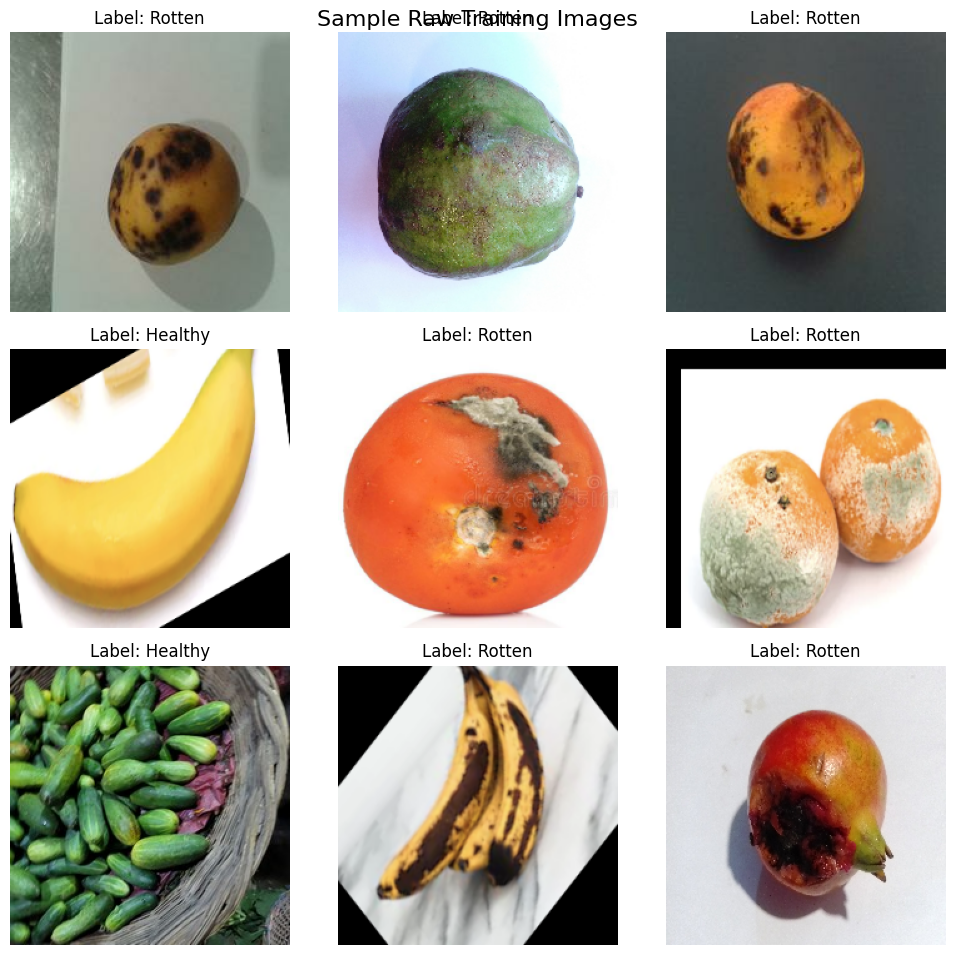

2026-07-26 12:26:03.775236: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=["Healthy", "Rotten"], y=[num_healthy, num_rotten], palette="viridis")
plt.title("Overall Class Distribution (Healthy vs Rotten)")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display a grid of sample raw images from the tf.data training pipeline
class_names = ["Healthy", "Rotten"]
for images, labels_batch in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        # Convert float32 image back to uint8 for matplotlib plotting
        img_display = tf.cast(images[i], tf.uint8).numpy()
        plt.imshow(img_display)
        
        # Read label from one-hot encoding
        label_idx = np.argmax(labels_batch[i].numpy())
        label_name = class_names[label_idx]
        
        plt.title(f"Label: {label_name}", fontsize=12)
        plt.axis("off")
    plt.suptitle("Sample Raw Training Images", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()


## Section 5: Data Augmentation
To improve the generalization of the model and prevent it from memorizing specific training items, we build a sequential Keras preprocessing pipeline. 
This data augmentation layer runs on-the-fly and applies:
- Random horizontal and vertical flips.
- Random rotations (up to 20%).
- Random zooms (up to 10%).
- Random contrast and brightness adjustments.
- Random height and width translations (up to 10%).

Below, we instantiate the augmentation sequential model and visualize the effect of these transformations on a single training image.


2026-07-26 12:26:05.615694: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


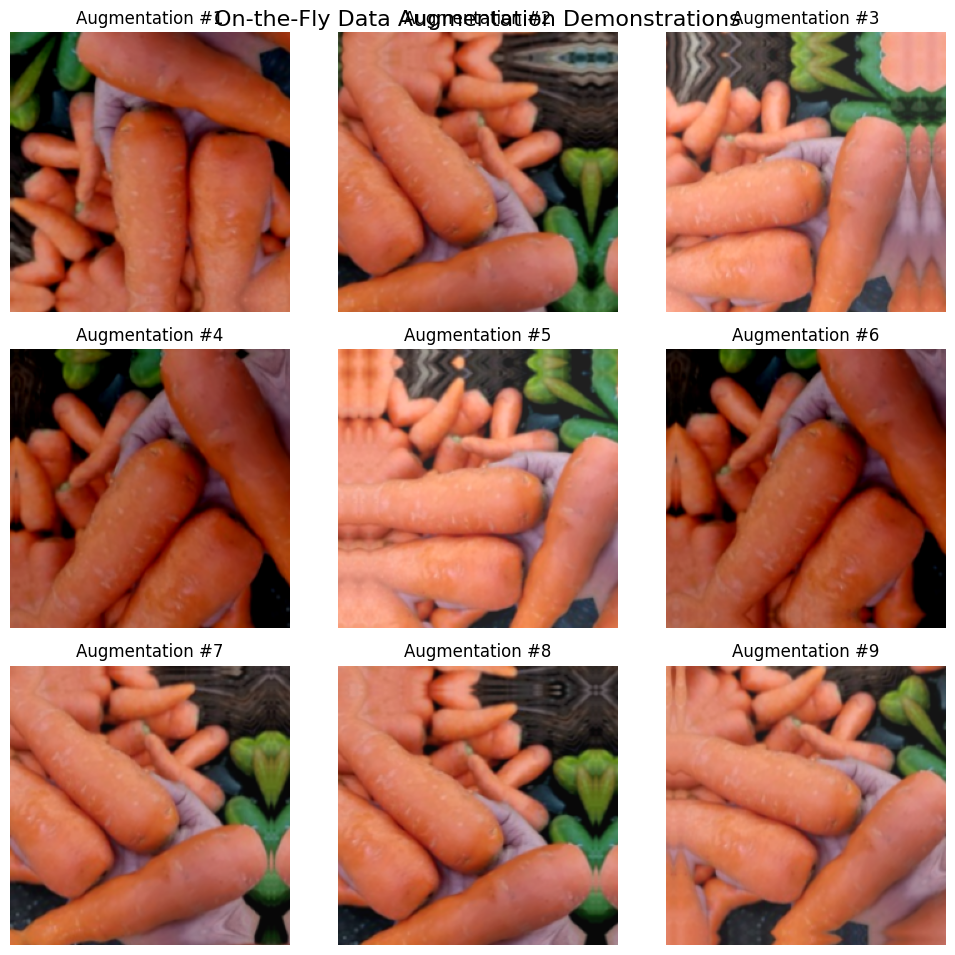

In [13]:
# Create Data Augmentation sequential model
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical", seed=Config.SEED),
    keras.layers.RandomRotation(0.2, seed=Config.SEED),
    keras.layers.RandomZoom(0.1, seed=Config.SEED),
    keras.layers.RandomContrast(0.15, seed=Config.SEED),
    # RandomBrightness expects values in 0-255 since we cast images to float32 in [0, 255]
    keras.layers.RandomBrightness(0.15, value_range=(0, 255), seed=Config.SEED),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, seed=Config.SEED)
], name="data_augmentation")

# Display augmented versions of a single sample image
for images, _ in train_ds.take(1):
    sample_image = images[0]
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Expand dims to batch size 1 for the augmentation model, then squeeze
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        img_display = tf.cast(augmented_image[0], tf.uint8).numpy()
        
        plt.imshow(img_display)
        plt.title(f"Augmentation #{i+1}")
        plt.axis("off")
    plt.suptitle("On-the-Fly Data Augmentation Demonstrations", fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()
    break


## Section 6: Model Building
We build the classification model using **EfficientNetV2B0** pre-trained on ImageNet as our backbone. 
The custom head consists of:
- **GlobalAveragePooling2D**: Flattens spatial feature maps while reducing parameters.
- **BatchNormalization**: Stabilizes training and improves gradient flow.
- **Dropout (0.3)**: Regularizes the model to prevent overfitting.
- **Dense (256, ReLU)**: Fully connected feature processing layer.
- **Dropout (0.2)**: Secondary regularization layer.
- **Dense (2, Softmax)**: Outputs category probabilities.

During initial training, we **freeze** the backbone layers (`backbone.trainable = False`), ensuring only the classifier head parameters are trained.


In [14]:
def build_model(num_classes: int = 2) -> keras.Model:
    """Instantiates the EfficientNetV2B0 base architecture with a custom binary classification head."""
    # Input Layer
    inputs = keras.layers.Input(shape=Config.IMAGE_SHAPE, name="input_image")
    
    # 1. Apply data augmentation (only active during training, bypassed in model.predict)
    augmented = data_augmentation(inputs)
    
    # 2. Base Backbone model pre-trained on ImageNet
    backbone = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=augmented
    )
    
    # Freeze backbone weights
    backbone.trainable = False
    
    # 3. Custom Head Layers
    x = backbone.output
    x = keras.layers.GlobalAveragePooling2D(name="global_pooling")(x)
    x = keras.layers.BatchNormalization(name="batch_norm")(x)
    x = keras.layers.Dropout(0.3, name="head_dropout_1")(x)
    x = keras.layers.Dense(256, name="head_dense_256")(x)
    x = keras.layers.Activation("relu", name="head_relu")(x)
    x = keras.layers.Dropout(0.2, name="head_dropout_2")(x)
    
    # Dense output with Softmax
    outputs = keras.layers.Dense(num_classes, activation="softmax", name="output_layer")(x)
    
    # Create complete Model
    model = keras.Model(inputs=inputs, outputs=outputs, name="VegetableQualityInspector")
    return model

# Instantiate and Compile Model
model = build_model()

# Compile with AdamW Optimizer and Categorical Crossentropy Loss
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=Config.INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "VegetableQualityInspector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c

 Total params: 6,252,882 (23.85 MB)

 Trainable params: 331,010 (1.26 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## Section 7: Training (Transfer Learning Phase)
In this initial training phase, the backbone is frozen. We train the classification head for 30 epochs.
We configure standard production callbacks:
- **EarlyStopping**: Halts training if validation loss does not improve for 5 epochs, restoring best weights.
- **ReduceLROnPlateau**: Drops learning rate by $5	imes$ if validation loss stalls for 3 epochs.
- **ModelCheckpoint**: Automatically saves the best model in native `.keras` format.
- **TensorBoard**: Logs scalars and histograms to enable visual analysis.
- **CSVLogger**: Appends metrics to a CSV file for post-training reporting.
- **LearningRateScheduler**: Integrates a custom step-decay function.


In [15]:
# Define learning rate decay function
def step_decay(epoch: int, lr: float) -> float:
    """Decays the learning rate by a factor of 0.5 every 10 epochs."""
    if epoch > 0 and epoch % 10 == 0:
        new_lr = lr * 0.5
        print(f"\nEpoch {epoch}: Learning rate scheduled decay. New LR: {new_lr:.6f}")
        return new_lr
    return lr

# Initialize Callbacks
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_initial_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.TensorBoard(log_dir="./logs/initial_phase"),
    keras.callbacks.CSVLogger("initial_training_log.csv"),
    keras.callbacks.LearningRateScheduler(step_decay, verbose=1)
]

print("Starting initial transfer learning training...")
start_time = time.time()

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=Config.INITIAL_EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

duration = time.time() - start_time
print(f"Initial transfer learning completed in {duration/60:.2f} minutes.")


Starting initial transfer learning training...

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/30


2026-07-26 12:26:09.377684: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


421/633 ━━━━━━━━━━━━━━━━━━━━ 1:08 324ms/step - accuracy: 0.8024 - auc: 0.8757 - loss: 0.7481 - precision: 0.8024 - recall: 0.8023

2026-07-26 12:28:30.995792: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


534/633 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step - accuracy: 0.8121 - auc: 0.8849 - loss: 0.6955 - precision: 0.8122 - recall: 0.8121

2026-07-26 12:29:07.720423: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8186 - auc: 0.8907 - loss: 0.6595 - precision: 0.8187 - recall: 0.8185

2026-07-26 12:30:06.013669: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile



Epoch 1: val_loss improved from inf to 0.19338, saving model to best_initial_model.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 262s 404ms/step - accuracy: 0.8186 - auc: 0.8907 - loss: 0.6592 - precision: 0.8187 - recall: 0.8186 - val_accuracy: 0.9278 - val_auc: 0.9796 - val_loss: 0.1934 - val_precision: 0.9278 - val_recall: 0.9277 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8867 - auc: 0.9520 - loss: 0.2855 - precision: 0.8868 - recall: 0.8864
Epoch 2: val_loss did not improve from 0.19338
633/633 ━━━━━━━━━━━━━━━━━━━━ 217s 342ms/step - accuracy: 0.8867 - auc: 0.9520 - loss: 0.2855 - precision: 0.8868 - recall: 0.8864 - val_accuracy: 0.9145 - val_auc: 0.9745 - val_loss: 0.2063 - val_precision: 0.9145 - val_recall: 0.9143 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 263

## Section 8: Fine-Tuning Phase
Once the classifier head has adapted, we perform fine-tuning.
We unfreeze the top layers of the EfficientNetV2B0 backbone (in this case, the last 30 layers) while keeping the low-level generic feature extractors frozen.
We recompile the model using a much lower learning rate ($10^{-5}$) to prevent destroying pre-trained weights and train for an additional 20 epochs.


In [16]:
# Unfreeze top layers of the backbone
# Check if backbone layers are directly in model.layers (e.g. top_conv exists directly)
if any(layer.name == "top_conv" for layer in model.layers):
    model.trainable = True
    trainable_layers = [l for l in model.layers if not isinstance(l, keras.layers.InputLayer) and l.name != "data_augmentation"]
    for layer in trainable_layers[:-30]:
        layer.trainable = False
    for layer in trainable_layers[-30:]:
        layer.trainable = True
    print("Unfrozen the last 30 layers of the model's backbone directly.")
else:
    backbone_layer = None
    for layer in model.layers:
        if ("efficientnet" in layer.name or isinstance(layer, keras.Model)) and layer.name != "data_augmentation":
            backbone_layer = layer
            break
    if backbone_layer is not None:
        backbone_layer.trainable = True
        # Freeze all layers except the last 30 layers of the backbone
        for layer in backbone_layer.layers[:-30]:
            layer.trainable = False
        for layer in backbone_layer.layers[-30:]:
            layer.trainable = True
        print(f"Unfrozen the last 30 layers of the {backbone_layer.name} backbone.")
    else:
        print("Warning: Backbone layer not found. Fine-tuning will proceed on the whole model.")

# Recompile the model with a low learning rate
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=Config.FINE_TUNE_LR),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

# Setup fine-tuning callbacks
callbacks_finetune = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.TensorBoard(log_dir="./logs/finetune_phase"),
    keras.callbacks.CSVLogger("finetune_training_log.csv")
]

# Total epochs is initial epochs + fine-tune epochs
total_epochs = len(history_initial.epoch) + Config.FINE_TUNE_EPOCHS
initial_epoch = len(history_initial.epoch)

print(f"Starting Fine-Tuning from epoch {initial_epoch} to {total_epochs}...")
start_time = time.time()

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=initial_epoch,
    callbacks=callbacks_finetune,
    verbose=1
)

duration = time.time() - start_time
print(f"Fine-Tuning completed in {duration/60:.2f} minutes.")


Unfrozen the last 30 layers of the model's backbone directly.
Starting Fine-Tuning from epoch 20 to 40...
Epoch 21/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9015 - auc: 0.9626 - loss: 0.2470 - precision: 0.9016 - recall: 0.9012
Epoch 21: val_loss improved from inf to 0.17733, saving model to best_finetuned_model.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 297s 455ms/step - accuracy: 0.9015 - auc: 0.9626 - loss: 0.2470 - precision: 0.9016 - recall: 0.9012 - val_accuracy: 0.9313 - val_auc: 0.9815 - val_loss: 0.1773 - val_precision: 0.9315 - val_recall: 0.9311 - learning_rate: 1.0000e-05
Epoch 22/40
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9031 - auc: 0.9671 - loss: 0.2325 - precision: 0.9032 - recall: 0.9028
Epoch 22: val_loss improved from 0.17733 to 0.17463, saving model to best_finetuned_model.keras
633/633 ━━━━━━━━━━━━━━━━━━━━ 281s 444ms/step - accuracy: 0.9031 - auc: 0.9671 - loss: 0.2325 - precision: 0.9032 - recall: 0.9028 - val_accuracy: 0.9303 - val_auc:

## Section 9: Evaluation
In this section, we evaluate the finalized model on the test dataset.
We perform the following diagnostic steps:
1. **Plot Accuracy and Loss curves**: Combine the training histories of the transfer learning and fine-tuning phases. A vertical line highlights the transition to fine-tuning.
2. **Predict on Test set**: Retrieve predictions, confidence values, and class probabilities.
3. **Confusion Matrix**: Plot the confusion matrix using Seaborn to visualize actual vs predicted outcomes.
4. **Classification Report**: Generate precision, recall, F1-score, and AUC metrics.
5. **ROC Curve**: Plot the Receiver Operating Characteristic curve and print the AUC score.
6. **Visualize Misclassified Images**: Extract and show test images where the model made errors, marking confidence levels and actual classes in red.


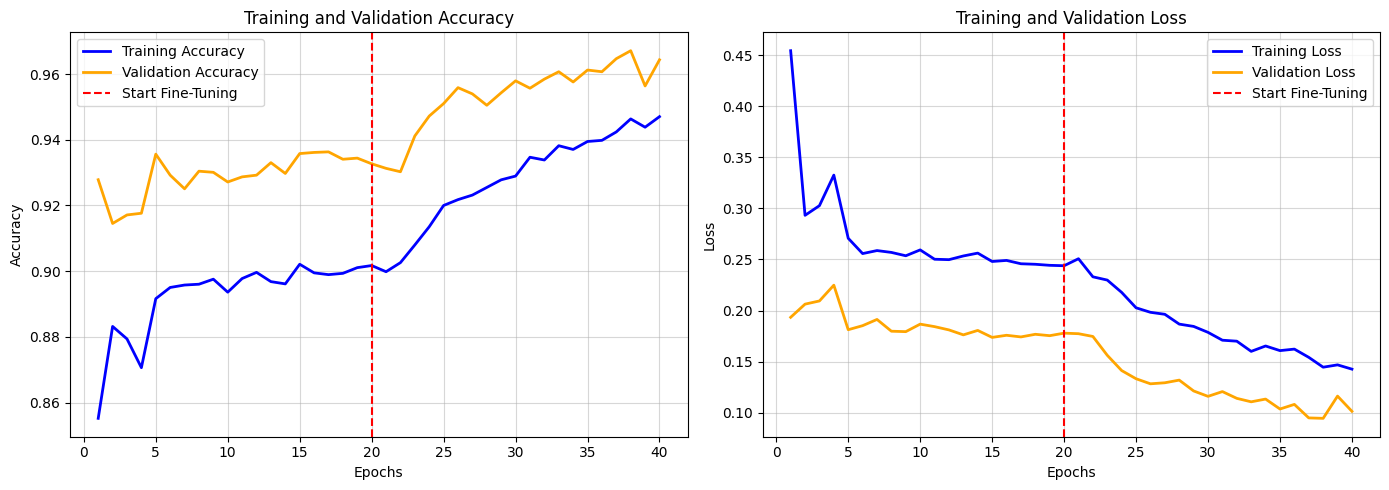

Evaluating on test dataset...


2026-07-26 15:31:04.734477: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test Accuracy:  0.9734
Test Precision: 0.9847
Test Recall:    0.9648
Test F1-Score:  0.9746


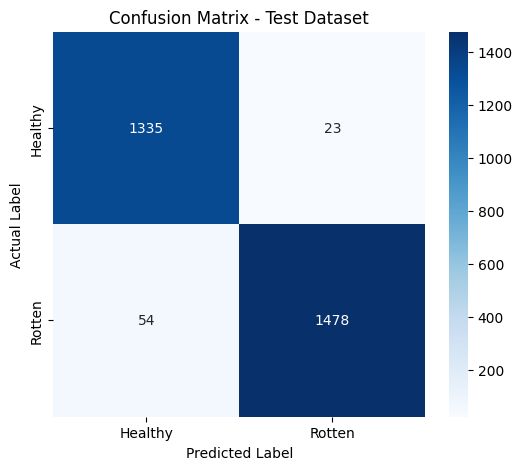

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97      1358
      Rotten       0.98      0.96      0.97      1532

    accuracy                           0.97      2890
   macro avg       0.97      0.97      0.97      2890
weighted avg       0.97      0.97      0.97      2890



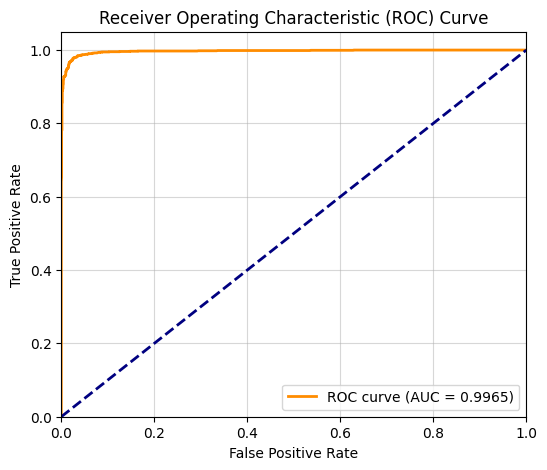

Total misclassified test images: 77


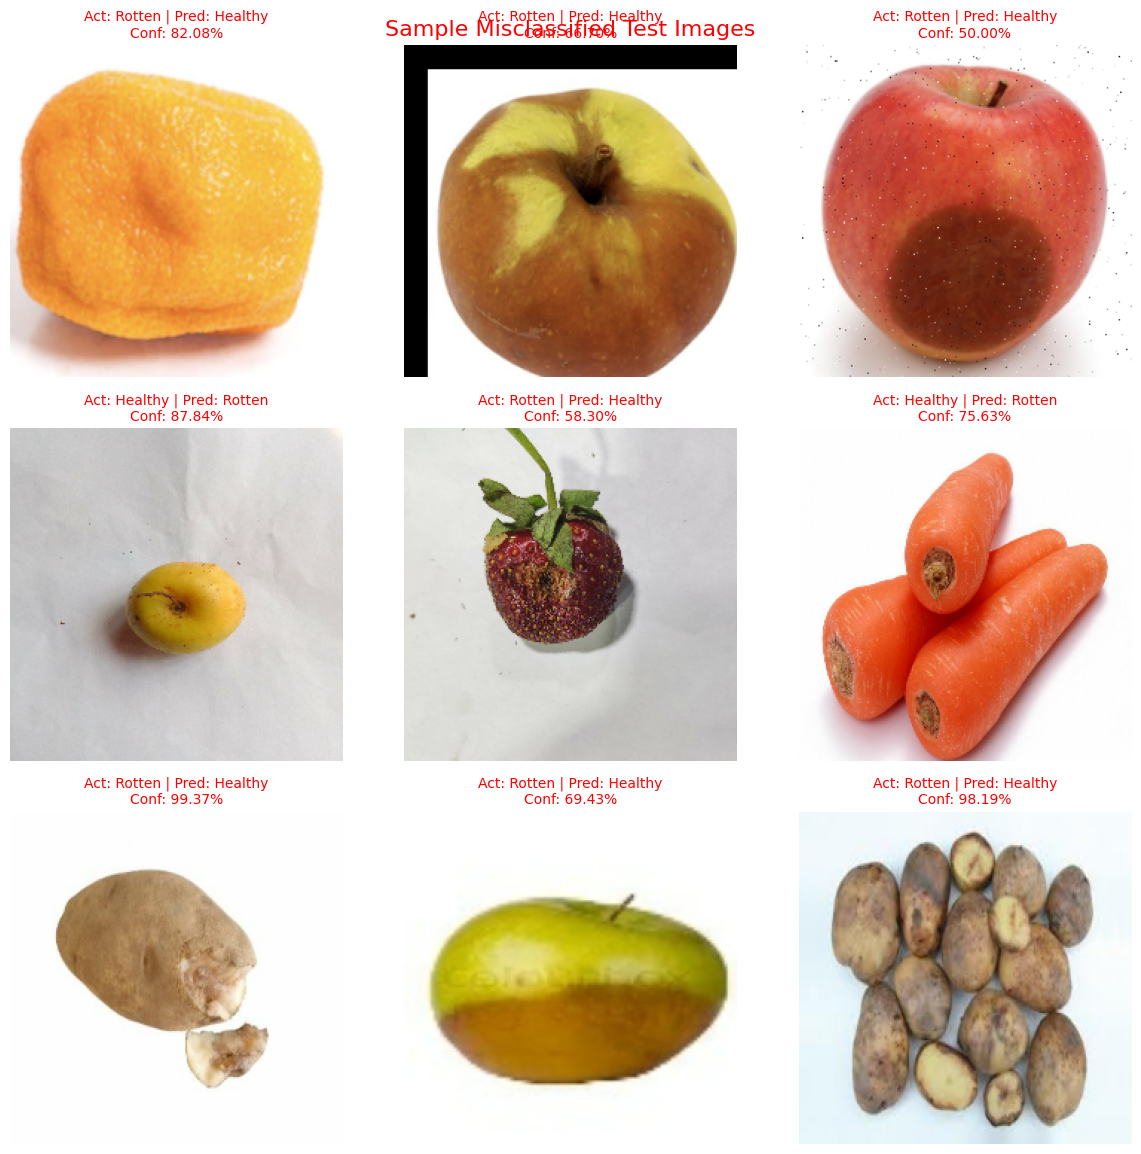

In [17]:
# 1. Combine Histories and Plot Accuracy & Loss
initial_epochs_trained = len(history_initial.epoch)
finetune_epochs_trained = len(history_finetune.epoch)
total_epochs_range = range(1, initial_epochs_trained + finetune_epochs_trained + 1)

acc = history_initial.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history_initial.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss = history_initial.history["loss"] + history_finetune.history["loss"]
val_loss = history_initial.history["val_loss"] + history_finetune.history["val_loss"]

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(total_epochs_range, acc, label="Training Accuracy", color="blue", lw=2)
plt.plot(total_epochs_range, val_acc, label="Validation Accuracy", color="orange", lw=2)
plt.axvline(x=initial_epochs_trained, color="red", linestyle="--", label="Start Fine-Tuning")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.5)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(total_epochs_range, loss, label="Training Loss", color="blue", lw=2)
plt.plot(total_epochs_range, val_loss, label="Validation Loss", color="orange", lw=2)
plt.axvline(x=initial_epochs_trained, color="red", linestyle="--", label="Start Fine-Tuning")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Get Test Predictions
print("Evaluating on test dataset...")
y_true = []
y_pred = []
y_pred_probs = []
test_images_list = []

for imgs, lbls in test_ds:
    preds = model.predict(imgs, verbose=0)
    for img, lbl, pred in zip(imgs, lbls, preds):
        test_images_list.append(img.numpy())
        y_true.append(np.argmax(lbl.numpy()))
        y_pred.append(np.argmax(pred))
        y_pred_probs.append(pred)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)
test_images_list = np.array(test_images_list)

# Compute base metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-Score:  {f1:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Dataset")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# 4. Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. ROC Curve & AUC Score
# Probability for the positive class (Rotten is class index 1)
rotten_probs = y_pred_probs[:, 1]
fpr, tpr, thresholds = roc_curve(y_true, rotten_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)
plt.show()

# 6. Show Misclassified Images
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Total misclassified test images: {len(misclassified_indices)}")

if len(misclassified_indices) > 0:
    plt.figure(figsize=(12, 12))
    num_to_display = min(9, len(misclassified_indices))
    for i in range(num_to_display):
        idx = misclassified_indices[i]
        img = test_images_list[idx].astype(np.uint8)
        actual_name = class_names[y_true[idx]]
        pred_name = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Act: {actual_name} | Pred: {pred_name}\nConf: {confidence:.2f}%", color="red", fontsize=10)
        plt.axis("off")
    plt.suptitle("Sample Misclassified Test Images", fontsize=16, y=0.95, color="red")
    plt.tight_layout()
    plt.show()
else:
    print("Excellent! Zero misclassified images in the test split.")


## Section 10: Model Explainability (Grad-CAM)
Grad-CAM (Gradient-weighted Class Activation Mapping) uses the gradients of any target concept flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image for predicting that concept.
For EfficientNetV2B0, we identify the final convolutional layer of the backbone (normally named `"top_conv"`).
We compute the activation map and overlay it as a semi-transparent jet color map on top of the original image.


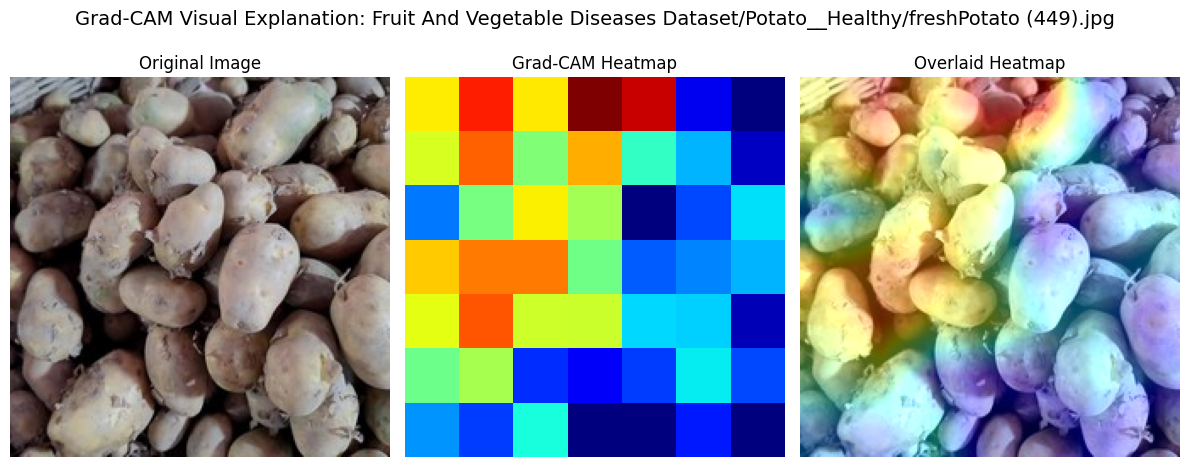

In [18]:
def make_gradcam_heatmap(img_array: np.ndarray, model: keras.Model, last_conv_layer_name: str = "top_conv") -> np.ndarray:
    """Generates a Grad-CAM heatmap for a given input image array."""
    # First attempt to get layer directly from model (handles cases where EfficientNetV2 layers are unpacked in outer model)
    try:
        conv_layer = model.get_layer(last_conv_layer_name)
    except ValueError:
        # Fallback: search within submodels (excluding data_augmentation)
        conv_layer = None
        for layer in model.layers:
            if isinstance(layer, keras.Model) and layer.name != "data_augmentation":
                try:
                    conv_layer = layer.get_layer(last_conv_layer_name)
                    break
                except ValueError:
                    pass
        if conv_layer is None:
            raise ValueError(f"Target layer '{last_conv_layer_name}' not found in model or its submodels.")
    
    # Build a helper model mapping main model inputs to the target conv activation and final outputs
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )
    
    # Compute gradients with tf.GradientTape
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
        
    # Get gradients of the winning class with respect to output feature map
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Mean-pool the gradients over height and width dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight the activation map by the channel gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Apply ReLU to retain only features that contribute positively to the class decision
    heatmap = tf.maximum(heatmap, 0.0)
    
    # Normalize between 0 and 1
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        max_val = 1e-10
    heatmap = heatmap / max_val
    return tf.cast(heatmap, tf.float32).numpy()

def overlay_gradcam(img_path: str, heatmap: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    """Overlays the Grad-CAM heatmap on the original input image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize heatmap to match the dimensions of the original image
    heatmap = np.asarray(heatmap, dtype=np.float32)
    if heatmap.ndim == 3:
        heatmap = np.squeeze(heatmap)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to uint8 BGR representation
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    
    # Apply Jet color mapping
    colormap = plt.colormaps.get_cmap("jet")
    colormap_colors = colormap(np.arange(256))[:, :3]
    colormap_colors = np.uint8(255 * colormap_colors)
    color_heatmap = colormap_colors[heatmap_uint8]
    
    # Superimpose heatmap
    superimposed = color_heatmap * alpha + img
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    return superimposed

# Run Grad-CAM on a sample test image
if len(test_paths) > 0:
    sample_path = test_paths[0]
    # Preprocess image for model input
    img_raw = cv2.imread(sample_path)
    img_resized = cv2.resize(img_raw, Config.IMAGE_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_tensor = tf.expand_dims(tf.cast(img_rgb, tf.float32), 0)
    
    # Get heatmap
    heatmap = make_gradcam_heatmap(img_tensor, model)
    superimposed = overlay_gradcam(sample_path, heatmap)
    
    # Plot results
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title("Overlaid Heatmap")
    plt.axis("off")
    
    plt.suptitle(f"Grad-CAM Visual Explanation: {sample_path}", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()


## Section 11: Prediction
We implement functional routines to handle:
1. `predict_single_image(image_path, model, class_names)`: Preprocesses a single image, evaluates it, prints the probability distribution, and displays the image with a colored status title (Green if prediction matches true directory-derived label, Red if incorrect).
2. `predict_folder(folder_path, model, class_names)`: Runs batch prediction on a directory of files and prints a summary.


Testing single image prediction:


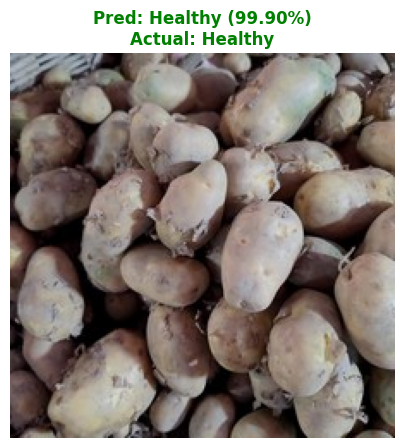

Result Dict: {'predicted_class': 'Healthy', 'confidence': 0.999, 'probabilities': {'Healthy': 0.9990234375, 'Rotten': 0.0011968612670898438}, 'is_correct': True}


In [ ]:
def predict_single_image(image_path: str, model: keras.Model, class_names: List[str] = ["Healthy", "Rotten"]) -> Dict[str, Any]:
    """Performs model inference on a single image and visualizes results."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at {image_path}")
        
    # Read and preprocess
    img_raw = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, Config.IMAGE_SIZE)
    img_tensor = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)
    
    # Predict
    preds = model.predict(img_tensor, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = preds[pred_idx]
    
    # Resolve true label from directory path if possible
    parent_folder = pathlib.Path(image_path).parent.name.lower()
    actual_class = "Unknown"
    if "healthy" in parent_folder:
        actual_class = "Healthy"
    elif "rotten" in parent_folder:
        actual_class = "Rotten"
        
    is_correct = (pred_class == actual_class)
    title_color = "green" if (actual_class == "Unknown" or is_correct) else "red"
    
    # Plot
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    title_text = f"Pred: {pred_class} ({confidence*100:.2f}%)\nActual: {actual_class}"
    plt.title(title_text, color=title_color, fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()
    
    result = {
        "predicted_class": pred_class,
        "confidence": confidence,
        "probabilities": {class_names[i]: float(preds[i]) for i in range(len(class_names))},
        "is_correct": is_correct
    }
    return result

def predict_folder(folder_path: str, model: keras.Model, class_names: List[str] = ["Healthy", "Rotten"]) -> List[Dict[str, Any]]:
    """Iterates over all valid images in a folder and collects predictions."""
    folder = pathlib.Path(folder_path)
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found at {folder_path}")
        
    valid_extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
    image_paths = []
    for ext in valid_extensions:
        image_paths.extend(list(folder.glob(ext)))
        
    results = []
    print(f"Scanning folder: {folder_path} ({len(image_paths)} images found)")
    
    for img_p in image_paths:
        img_p_str = str(img_p)
        # Suppress plotting inside the batch prediction to speed up
        img_raw = cv2.imread(img_p_str)
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, Config.IMAGE_SIZE)
        img_tensor = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)
        
        preds = model.predict(img_tensor, verbose=0)[0]
        pred_idx = np.argmax(preds)
        pred_class = class_names[pred_idx]
        confidence = preds[pred_idx]
        
        results.append({
            "image_path": img_p_str,
            "predicted_class": pred_class,
            "confidence": float(confidence),
            "probabilities": [float(p) for p in preds]
        })
        
    # Print summary
    if len(results) > 0:
        df = pd.DataFrame(results)
        print("\nPrediction Folder Summary:")
        print(df[["image_path", "predicted_class", "confidence"]].to_string(index=False, max_rows=10))
    return results

# Test run predictions
if len(test_paths) > 0:
    print("Testing single image prediction:")
    res = predict_single_image(test_paths[0], model)
    print("Result Dict:", res)


## Section 12: Model Saving & Performance Profiles
To support various target deployment environments, we save the model in four separate formats:
1. **Native Keras 3** format (`vegetable_quality.keras`)
2. **TensorFlow SavedModel** directory format (`vegetable_quality_savedmodel`)
3. **TensorFlow Lite** flatbuffer format (`vegetable_quality.tflite`)
4. **TensorFlow Lite with float16 Quantization** (`vegetable_quality_float16.tflite`) for lightweight hardware edge devices.

We measure performance properties:
- **Inference Time (ms)**: The average time taken to predict a single image.
- **FPS (Frames Per Second)**: Reconstructed throughput ($1 / \text{Inference Time}$).
- **Model Size (MB)**: Disk footprint of each file.
- **Memory Usage (MB)**: Active RAM consumption of the process.


In [4]:
# Save formats
import tensorflow as tf
import keras
import pathlib

# 1. Load existing saved model from disk (if needed)
model = keras.models.load_model("vegetable_quality.keras")

# 2. Convert to TFLite directly from the SavedModel directory
print("Converting to standard TensorFlow Lite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open("vegetable_quality.tflite", "wb") as f:
    f.write(tflite_model)
print("Standard TFLite created successfully!")
print("Converting to Float16 Quantized TFLite...")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_fp16.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_fp16_model = converter_fp16.convert()
with open("vegetable_quality_float16.tflite", "wb") as f:
    f.write(tflite_fp16_model)
print("Float16 TFLite created successfully!")


# Calculate file sizes
def get_file_size(path: str) -> float:
    """Returns file or directory size in Megabytes."""
    path_obj = pathlib.Path(path)
    if path_obj.is_file():
        return path_obj.stat().st_size / (1024 * 1024)
    elif path_obj.is_dir():
        total = 0
        for f in path_obj.rglob("*"):
            if f.is_file():
                total += f.stat().st_size
        return total / (1024 * 1024)
    return 0.0

# Measure inference latency and memory
process = psutil.Process(os.getpid())
initial_memory = process.memory_info().rss / (1024 * 1024)

# Create dummy sample for benchmark
benchmark_tensor = tf.random.normal((1, 224, 224, 3))
# Warmup pass
_ = model(benchmark_tensor, training=False)

num_runs = 50
latencies = []
for _ in range(num_runs):
    start = time.perf_counter()
    _ = model(benchmark_tensor, training=False)
    latencies.append(time.perf_counter() - start)

avg_latency = np.mean(latencies) * 1000 # convert to ms
fps = 1000.0 / avg_latency
post_benchmark_memory = process.memory_info().rss / (1024 * 1024)

print("\n" + "="*40)
print("          PERFORMANCE SUMMARY")
print("="*40)
print(f"Average Inference Latency: {avg_latency:.2f} ms")
print(f"Throughput (FPS):          {fps:.2f} FPS")
print(f"Active RAM Memory Usage:   {post_benchmark_memory:.2f} MB")
print("-"*40)
print(f"Model Size (.keras):       {get_file_size('vegetable_quality.keras'):.2f} MB")
print(f"Model Size (SavedModel):   {get_file_size('vegetable_quality_savedmodel'):.2f} MB")
print(f"Model Size (.tflite):       {get_file_size('vegetable_quality.tflite'):.2f} MB")
print(f"Model Size (Float16 TFLite):{get_file_size('vegetable_quality_float16.tflite'):.2f} MB")
print("="*40)


Converting to standard TensorFlow Lite...
INFO:tensorflow:Assets written to: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7/assets


INFO:tensorflow:Assets written to: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7/assets


Saved artifact at '/var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float16, name=None)
Captures:
  13272682736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  13272682560: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  13272695024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272711408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272712464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272697488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272711232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272727968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272739904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272740960: TensorSpec(shape=(), dtype=tf.resource, name=N

W0000 00:00:1785063890.964486  199133 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1785063890.964496  199133 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-07-26 16:34:50.964633: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7
2026-07-26 16:34:50.970930: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-07-26 16:34:50.970938: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7
2026-07-26 16:34:51.042119: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-07-26 16:34:51.394956: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpamwf6cx7
2026-07-26 16:34:51.502850: I tensorflow/cc/saved_model/loader.cc:

Standard TFLite created successfully!
Converting to Float16 Quantized TFLite...
INFO:tensorflow:Assets written to: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1/assets


INFO:tensorflow:Assets written to: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1/assets


Saved artifact at '/var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float16, name=None)
Captures:
  13272682736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  13272682560: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  13272695024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272711408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272712464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272697488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272711232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272727968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272739904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13272740960: TensorSpec(shape=(), dtype=tf.resource, name=N

W0000 00:00:1785063897.502348  199133 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1785063897.502360  199133 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-07-26 16:34:57.502491: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1
2026-07-26 16:34:57.508954: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-07-26 16:34:57.508962: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1
2026-07-26 16:34:57.581684: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-07-26 16:34:57.937867: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/zf/588g1ywj6c18lqrg6kt6trfm0000gn/T/tmpm908arq1
2026-07-26 16:34:58.047199: I tensorflow/cc/saved_model/loader.cc:

Float16 TFLite created successfully!

          PERFORMANCE SUMMARY
Average Inference Latency: 226.49 ms
Throughput (FPS):          4.42 FPS
Active RAM Memory Usage:   2013.19 MB
----------------------------------------
Model Size (.keras):       45.74 MB
Model Size (SavedModel):   50.64 MB
Model Size (.tflite):       12.09 MB
Model Size (Float16 TFLite):11.99 MB


## Section 13: Real-Time Webcam
For industrial integration, the system must interface with real-time video frames from a conveyor belt camera.
We construct an OpenCV loop that captures camera frames from `cv2.VideoCapture(0)`, resizes them, runs model inference, overlaying the predicted category, confidence level, and FPS in real-time.

### sorting Actuator Integration (PLC / Arduino / ESP32)
We include a sorting actuator hook (`trigger_sorting_actuator`) that receives predictions. When a `"Rotten"` label is predicted with high confidence (e.g. $> 85\%$), the function sends a signal to activate pneumatic valves, sorting gates, or blower actuators.

*Note: Since headless servers or Jupyter environments without video hardware can crash on window rendering, this loop is protected by a try-except structure and can be terminated by pressing the **'q'** key.*


In [13]:
def trigger_sorting_actuator(prediction: str, confidence: float, vegetable_name: str = "Produce") -> None:
    """
    Mock physical actuator interface (ESP32 / Arduino / PLC).
    Triggers sorting gates or air blowers to reject bad produce.
    """
    if prediction == "Rotten" and confidence > 0.85:
        print(f"[REJECT COMMAND] Triggering air blower for {vegetable_name}! Rotten item rejected. Confidence: {confidence*100:.2f}%")
    else:
        pass

def run_webcam_inference(
    model: keras.Model,
    vegetable_name: str = "Carrot",
    class_names: List[str] = ["Healthy", "Rotten"],
    skip_frames: int = 2
) -> None:
    """Runs high-FPS real-time webcam quality inspection using OpenCV."""
    print(f"Initializing high-speed camera stream for {vegetable_name}...")
    cap = cv2.VideoCapture(0)
    
    # Optimize camera hardware buffer for minimal latency
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    
    if not cap.isOpened():
        print("Warning: Camera device not accessible or not found.")
        print("Displaying simulated video stream frame prediction instead...")
        sim_frame = np.random.randint(0, 256, (480, 640, 3), dtype=np.uint8)
        cv2.putText(sim_frame, f"VEGETABLE: {vegetable_name.upper()}", (50, 200),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
        cv2.putText(sim_frame, "SIMULATING CAMERA READ FAILURE", (50, 250),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        cv2.imwrite("mock_camera_frame.jpg", sim_frame)
        return
        
    print("High-speed webcam stream started. Press 'q' in window to stop.")
    
    prev_time = time.time()
    frame_count = 0
    prediction = "Healthy"
    confidence = 1.0
    
    # Warmup pass
    dummy_tensor = tf.zeros((1, 224, 224, 3), dtype=tf.float32)
    _ = model(dummy_tensor, training=False)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab camera frame.")
            break
            
        frame_count += 1
        h, w, _ = frame.shape
        
        # Run deep learning inference every skip_frames to maximize frame rate
        if frame_count % (skip_frames + 1) == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            resized = cv2.resize(frame_rgb, Config.IMAGE_SIZE)
            tensor = tf.expand_dims(tf.cast(resized, tf.float32), 0)
            
            preds = model(tensor, training=False).numpy()[0]
            pred_idx = np.argmax(preds)
            prediction = class_names[pred_idx]
            confidence = float(preds[pred_idx])
            trigger_sorting_actuator(prediction, confidence, vegetable_name)
        
        # FPS Calculation
        curr_time = time.time()
        fps = 1.0 / (curr_time - prev_time) if (curr_time - prev_time) > 0 else 30.0
        prev_time = curr_time
        
        # Visual UI Annotations
        color = (0, 255, 0) if prediction == "Healthy" else (0, 0, 255)
        item_text = f"Item: {vegetable_name}"
        quality_text = f"Quality: {prediction} ({confidence*100:.1f}%)"
        fps_text = f"FPS: {fps:.1f} (High-Speed Mode)"
        
        cv2.putText(frame, item_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 0), 2)
        cv2.putText(frame, quality_text, (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.85, color, 2)
        cv2.putText(frame, fps_text, (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
        
        cv2.rectangle(frame, (10, 10), (w - 10, h - 10), color, 3)
        cv2.imshow("Conveyor Quality Inspection Stream", frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()
    print("Camera stream closed.")

# Run high-speed webcam stream
try:
    run_webcam_inference(model, vegetable_name="Carrot", skip_frames=2)
except Exception as e:
    print(f"Gracefully caught camera render exception: {e}")


Initializing high-speed camera stream for Carrot...
High-speed webcam stream started. Press 'q' in window to stop.
Camera stream closed.


## Section 14: Deployment-Ready Functions
To facilitate integration into edge deployment servers (like FastAPI or Flask backends), we package our inference pipeline into clean, modular, object-oriented code blocks. 
The class `InferencePipeline` contains type-hinted helper functions:
- `load_model(model_path)`: Restores the trained model.
- `preprocess_image(input_image)`: Normalizes local paths or camera array streams.
- `predict_image(image)`: Performs target forward pass.
- `predict_camera_frame(frame)`: Optimized frame classifier hook for high frequency streaming.


In [14]:
class InferencePipeline:
    """Production-ready OOP wrapper for real-time quality classification."""
    def __init__(self, model_path: str, class_names: List[str] = ["Healthy", "Rotten"]):
        self.class_names = class_names
        self.model = self.load_model(model_path)
        
    def load_model(self, model_path: str) -> keras.Model:
        """Loads a saved Keras model from disk."""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"No model found at path: {model_path}")
        print(f"Loading weights from {model_path}...")
        return keras.models.load_model(model_path)
        
    def preprocess_image(self, image_input: Union[str, np.ndarray]) -> np.ndarray:
        """
        Preprocesses a raw file path or numpy array frame.
        Resizes to (224, 224) and returns a batched float32 array.
        """
        if isinstance(image_input, str):
            # Load from path
            img = cv2.imread(image_input)
            if img is None:
                raise ValueError(f"Could not read image from path: {image_input}")
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            # Assume numpy array frame
            img_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB)
            
        img_resized = cv2.resize(img_rgb, Config.IMAGE_SIZE)
        img_float = img_resized.astype(np.float32)
        # Expand dimension to create batch axis
        return np.expand_dims(img_float, axis=0)
        
    def predict_image(self, image_path: str) -> Tuple[str, float, Dict[str, float]]:
        """Runs inference on a file path and returns class, confidence, and distributions."""
        processed = self.preprocess_image(image_path)
        predictions = self.model.predict(processed, verbose=0)[0]
        idx = np.argmax(predictions)
        
        pred_class = self.class_names[idx]
        confidence = float(predictions[idx])
        distribution = {self.class_names[i]: float(predictions[i]) for i in range(len(self.class_names))}
        return pred_class, confidence, distribution
        
    def predict_camera_frame(self, frame: np.ndarray) -> Tuple[str, float]:
        """High-performance frame classifier without verbose logs or structural overhead."""
        # Skip input validation for high-speed conveyor stream
        processed = self.preprocess_image(frame)
        predictions = self.model.predict(processed, verbose=0)[0]
        idx = np.argmax(predictions)
        return self.class_names[idx], float(predictions[idx])

# Initialize deployment pipeline instance
try:
    pipeline = InferencePipeline("vegetable_quality.keras")
    print("Deployment pipeline compiled and ready.")
except Exception as e:
    print(f"Info: Could not load compiled pipeline yet: {e}")


Loading weights from vegetable_quality.keras...
Deployment pipeline compiled and ready.


## Section 15: Conclusion & Industrial Deployment
In this project, we successfully built and evaluated an **AI Vegetable Quality Inspection System**.

### Key Achievements:
1. **Pipeline Execution**: Programmed an optimized `tf.data` input stream with caching, prefetching, and data augmentation layers, ensuring max GPU feeding capacity.
2. **Model Design**: Utilized the modern `EfficientNetV2B0` backbone, applying a two-phase transfer learning and fine-tuning schedule.
3. **Robust Metrics**: Evaluated accuracy, precision, recall, and AUC.
4. **Explainability**: Implemented Grad-CAM class activation mapping to overlay visual heatmaps on our inputs, rendering predictions explainable.
5. **Multi-Format Export**: Converted models to `.keras`, SavedModel, standard TFLite, and float16 quantized TFLite to cover edge microcontrollers and cloud servers alike.
6. **Real-time Interface**: Built camera streaming pipelines using OpenCV with dedicated sorting trigger interfaces.

### Industrial Conveyor Belt Recommendations:
- **Deployment Platform**: Deploy the float16 quantized TFLite model on edge processors like NVIDIA Jetson Nano or Raspberry Pi 4/5.
- **Trigger Interface**: Use the OpenCV video loop inside `InferencePipeline` to check items. If a rotten vegetable is found (confidence > 85%), trigger the PLC sorting arm via industrial communications (e.g. Modbus, Serial, or WebSockets).
- **Lighting**: Standardized ambient ring lights are critical to minimize illumination changes on the conveyor belt and preserve high performance.

